# Step 7 — Validate Simulator Against Real Logs

This notebook completes **Step 7 only**.

Goal: compare simulated outputs with real process behavior and produce a pass/fail validation report before PPO training.

## What we do in this step (simple view)

1. Load real case-step data and simulated trace/episode outputs.
2. Compute five comparison metrics.
3. Plot side-by-side distributions.
4. Apply baseline thresholds.
5. Save `sim_validation_report.csv`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('./output')

REAL_FEATURES_PARQUET = OUTPUT_DIR / 'case_step_features.parquet'
REAL_FEATURES_CSV = OUTPUT_DIR / 'case_step_features.csv'
SIM_TRACE_PATH = OUTPUT_DIR / 'sim_trace_table.csv'
SIM_EPISODE_PATH = OUTPUT_DIR / 'sim_episode_summary.csv'
VALIDATION_REPORT_PATH = OUTPUT_DIR / 'sim_validation_report.csv'
VALIDATION_BY_RUN_PATH = OUTPUT_DIR / 'sim_validation_metrics_by_run.csv'

print('Output dir:', OUTPUT_DIR.resolve())

Output dir: /mnt/HDD/Code/Git/bureaucratic-workflow-analyzer/output


In [2]:
# Load real data
if not REAL_FEATURES_PARQUET.exists():
    print('Error: previous notebook should be run first (Step 2 missing case_step_features.parquet).')
    raise SystemExit(1)
real_df = pd.read_parquet(REAL_FEATURES_PARQUET)
real_loaded_from = REAL_FEATURES_PARQUET

# Load simulator outputs
if not SIM_TRACE_PATH.exists() or not SIM_EPISODE_PATH.exists():
    print('Error: previous notebook should be run first (Step 6 simulator outputs missing).')
    raise SystemExit(1)

sim_trace_df = pd.read_csv(SIM_TRACE_PATH)
sim_episode_df = pd.read_csv(SIM_EPISODE_PATH)

# Normalize timestamps
real_df['timestamp'] = pd.to_datetime(real_df['timestamp'], utc=True, errors='coerce')
sim_trace_df['timestamp'] = pd.to_datetime(sim_trace_df['timestamp'], utc=True, errors='coerce')
print(f'Real rows: {len(real_df):,}  (from {real_loaded_from.name})')
print(f'Sim trace rows: {len(sim_trace_df):,}')
print(f'Sim episode rows: {len(sim_episode_df):,}')

Real rows: 262,628  (from case_step_features.parquet)
Sim trace rows: 405,731
Sim episode rows: 12,000


## 7.1 Build case-level real and simulated summaries

The helper functions below compute comparable episode-level statistics from real and simulated traces.

In [3]:
def build_real_case_summary(real_features: pd.DataFrame):
    """Create case-level summary from real data (trace length, duration, loops, completion)."""
    base = real_features.sort_values(['municipality', 'case_id', 'step_index'])

    case_steps = base.groupby(['municipality', 'case_id'])['step_index'].max().add(1).rename('steps')

    case_duration = (
        base.groupby(['municipality', 'case_id'])['time_since_case_start_hours']
        .max()
        .rename('duration_hours')
    )

    # loops = number of activities repeated within case
    def loops_for_case(df_case):
        counts = df_case['activity'].value_counts()
        return int((counts > 1).sum())

    case_loops = base.groupby(['municipality', 'case_id']).apply(loops_for_case).rename('loops')

    # completed = whether case has any step with case_completed = True
    case_completed = base.groupby(['municipality', 'case_id'])['case_completed'].max().rename('case_completed')

    out = pd.concat([case_steps, case_duration, case_loops, case_completed], axis=1).reset_index()
    return out

def build_sim_case_summary(sim_trace: pd.DataFrame, sim_episode: pd.DataFrame):
    """Create case-level summary for simulated data (prefer episode table, fallback from trace)."""
    needed_cols = {'municipality', 'case_id', 'steps', 'duration_hours', 'loops', 'case_completed'}
    if needed_cols.issubset(sim_episode.columns):
        out = sim_episode[['municipality', 'case_id', 'steps', 'duration_hours', 'loops', 'case_completed']].copy()
        return out

    base = sim_trace.sort_values(['municipality', 'case_id', 'step_index'])
    case_steps = base.groupby(['municipality', 'case_id'])['step_index'].max().add(1).rename('steps')
    case_duration = base.groupby(['municipality', 'case_id'])['time_since_case_start_hours'].max().rename('duration_hours')

    def loops_for_case(df_case):
        counts = df_case['activity'].value_counts()
        return int((counts > 1).sum())

    case_loops = base.groupby(['municipality', 'case_id']).apply(loops_for_case).rename('loops')
    case_completed = base.groupby(['municipality', 'case_id'])['case_completed'].max().rename('case_completed')
    out = pd.concat([case_steps, case_duration, case_loops, case_completed], axis=1).reset_index()
    return out

real_case_summary = build_real_case_summary(real_df)
sim_case_summary = build_sim_case_summary(sim_trace_df, sim_episode_df)

print('Real cases:', len(real_case_summary))
print('Sim cases :', len(sim_case_summary))
sim_case_summary.head()

Real cases: 5649
Sim cases : 12000


,municipality,case_id,steps,duration_hours,loops,case_completed
0,1,R01_M1_SIM_00000,39,511.008318,2,False
1,1,R01_M1_SIM_00001,38,570.635880,1,True
2,1,R01_M1_SIM_00002,32,1028.759273,3,True
3,1,R01_M1_SIM_00003,33,390.755177,0,False
4,1,R01_M1_SIM_00004,38,86.815219,1,True


## 7.2 Compute comparison metrics

Metrics:
1. Trace length distribution
2. Activity frequency distribution
3. Transition frequency matrix distance
4. Case duration distribution
5. Loop/rework frequency

In [4]:
def relative_error(real_value, sim_value):
    """Compute absolute relative error with safe zero handling."""
    real_value = float(real_value)
    sim_value = float(sim_value)
    denom = max(abs(real_value), 1e-9)
    return abs(sim_value - real_value) / denom


def distribution_l1_distance(real_series, sim_series):
    """Compute L1 distance between normalized value-count distributions."""
    r = real_series.value_counts(normalize=True)
    s = sim_series.value_counts(normalize=True)
    idx = sorted(set(r.index).union(set(s.index)))
    rv = np.array([float(r.get(i, 0.0)) for i in idx])
    sv = np.array([float(s.get(i, 0.0)) for i in idx])
    return float(np.abs(rv - sv).sum())


def normalized_transition_distance(real_transitions, sim_transitions):
    """Compute normalized L1 distance on transition probabilities over edge union."""
    r = real_transitions.value_counts(normalize=True)
    s = sim_transitions.value_counts(normalize=True)

    idx = list(dict.fromkeys(list(r.index) + list(s.index)))
    rv = np.array([float(r.get(i, 0.0)) for i in idx])
    sv = np.array([float(s.get(i, 0.0)) for i in idx])
    return float(np.abs(rv - sv).sum())


def build_transition_series(df):
    trans_df = df[['activity', 'next_activity']].copy()
    trans_df = trans_df[trans_df['next_activity'].notna()]
    trans_df['activity'] = trans_df['activity'].astype(str)
    trans_df['next_activity'] = trans_df['next_activity'].astype(str)
    trans_df = trans_df[~trans_df['next_activity'].isin(['', 'nan', 'None'])]
    return pd.Series(list(zip(trans_df['activity'], trans_df['next_activity'])))


real_act = real_df['activity'].value_counts(normalize=True)
top_acts = real_act.head(20).index.tolist()
real_top20_mass = float(real_act.reindex(top_acts).fillna(0.0).sum())

real_trans = build_transition_series(real_df)
real_unique_edges = float(real_trans.nunique())

real_trace_median_steps = float(real_case_summary['steps'].median())
real_duration_median = float(real_case_summary['duration_hours'].median())
real_loop_mean = float(real_case_summary['loops'].mean())

if 'run_id' not in sim_trace_df.columns:
    sim_trace_df['run_id'] = 1
if 'run_id' not in sim_episode_df.columns:
    sim_episode_df['run_id'] = 1

sim_trace_df['run_id'] = pd.to_numeric(sim_trace_df['run_id'], errors='coerce').fillna(1).astype(int)
sim_episode_df['run_id'] = pd.to_numeric(sim_episode_df['run_id'], errors='coerce').fillna(1).astype(int)

run_ids = sorted(set(sim_trace_df['run_id'].unique()).intersection(set(sim_episode_df['run_id'].unique())))
if not run_ids:
    raise RuntimeError('No common run_id found between sim trace and sim episode tables.')

run_metric_rows = []
for run_id in run_ids:
    sim_trace_run = sim_trace_df[sim_trace_df['run_id'] == run_id].copy()
    sim_episode_run = sim_episode_df[sim_episode_df['run_id'] == run_id].copy()
    sim_case_summary_run = build_sim_case_summary(sim_trace_run, sim_episode_run)

    trace_length_dist_l1 = distribution_l1_distance(real_case_summary['steps'], sim_case_summary_run['steps'])

    sim_act_run = sim_trace_run['activity'].value_counts(normalize=True)
    top_act_rel_errors = [relative_error(real_act[a], float(sim_act_run.get(a, 0.0))) for a in top_acts]
    top_act_rel_error_mean = float(np.mean(top_act_rel_errors)) if top_act_rel_errors else np.nan

    sim_trans = build_transition_series(sim_trace_run)
    transition_matrix_l1 = normalized_transition_distance(real_trans, sim_trans)

    sim_duration_median = float(sim_case_summary_run['duration_hours'].median())
    duration_median_rel_error = relative_error(real_duration_median, sim_duration_median)

    sim_loop_mean = float(sim_case_summary_run['loops'].mean())
    loop_rel_error = relative_error(real_loop_mean, sim_loop_mean)

    sim_trace_median_steps = float(sim_case_summary_run['steps'].median())
    sim_top20_mass = float(sim_act_run.reindex(top_acts).fillna(0.0).sum())
    sim_unique_edges = float(sim_trans.nunique())

    run_metric_rows.append({
        'run_id': int(run_id),
        'trace_length_dist_l1': trace_length_dist_l1,
        'top20_activity_rel_error_mean': top_act_rel_error_mean,
        'transition_matrix_l1': transition_matrix_l1,
        'duration_median_rel_error': duration_median_rel_error,
        'loop_rel_error': loop_rel_error,
        'sim_trace_median_steps': sim_trace_median_steps,
        'sim_top20_mass': sim_top20_mass,
        'sim_unique_edges': sim_unique_edges,
        'sim_duration_median': sim_duration_median,
        'sim_loop_mean': sim_loop_mean,
    })

metrics_by_run_df = pd.DataFrame(run_metric_rows).sort_values('run_id').reset_index(drop=True)
metrics_by_run_df.to_csv(VALIDATION_BY_RUN_PATH, index=False)

metric_cols = [
    'trace_length_dist_l1',
    'top20_activity_rel_error_mean',
    'transition_matrix_l1',
    'duration_median_rel_error',
    'loop_rel_error',
]
metrics_snapshot = (
    metrics_by_run_df[metric_cols]
    .agg(['mean', 'std', 'min', 'max'])
    .T
    .reset_index()
    .rename(columns={'index': 'metric'})
)

plot_run_id = int(run_ids[0])
sim_trace_for_plot = sim_trace_df[sim_trace_df['run_id'] == plot_run_id].copy()
sim_episode_for_plot = sim_episode_df[sim_episode_df['run_id'] == plot_run_id].copy()
sim_case_summary = build_sim_case_summary(sim_trace_for_plot, sim_episode_for_plot)

print('Detected simulation runs:', len(run_ids))
print('Using run for plots:', plot_run_id)
print('Saved per-run metrics:', VALIDATION_BY_RUN_PATH.resolve())
metrics_snapshot

Detected simulation runs: 20
Using run for plots: 1
Saved per-run metrics: /mnt/HDD/Code/Git/bureaucratic-workflow-analyzer/output/sim_validation_metrics_by_run.csv


,metric,mean,std,min,max
0,trace_length_dist_l1,1.049867,0.035211,0.993548,1.118812
1,top20_activity_rel_error_mean,0.162852,0.009648,0.147233,0.189538
2,transition_matrix_l1,0.392730,0.007023,0.378932,0.405963
3,duration_median_rel_error,0.279835,0.019729,0.236773,0.310950
4,loop_rel_error,0.390477,0.027419,0.337414,0.443286


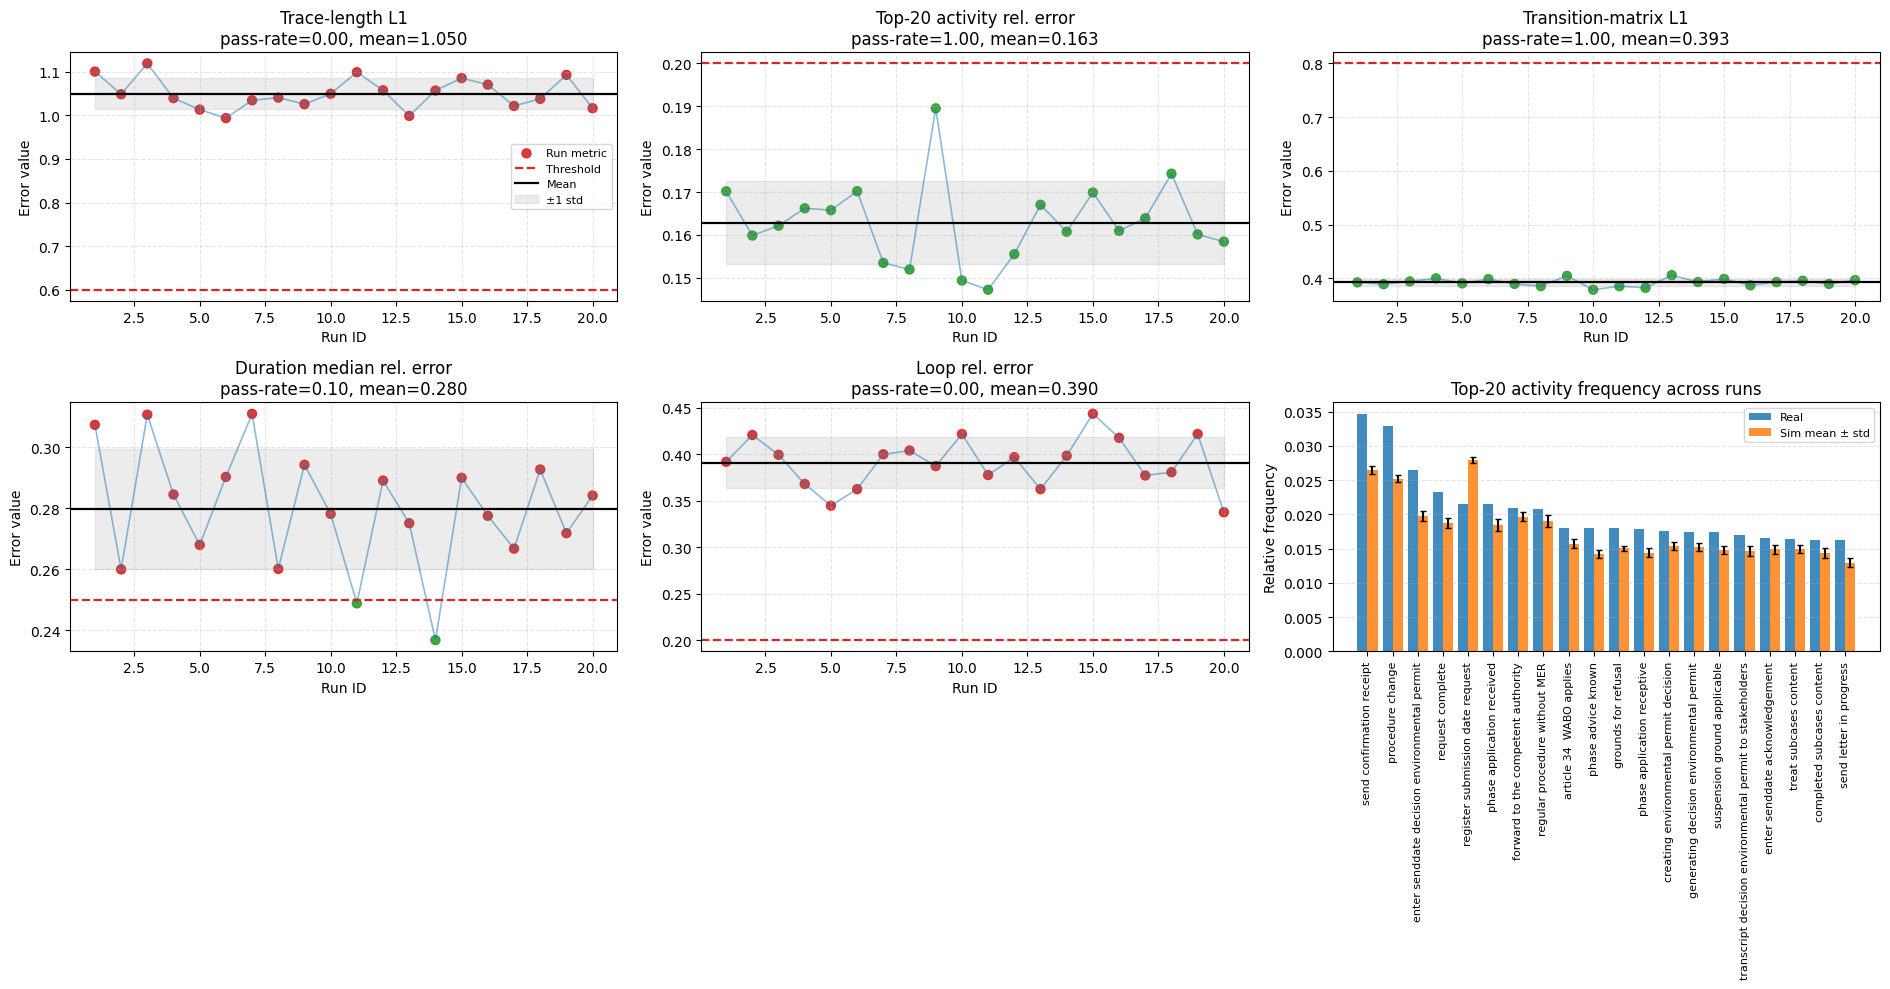

In [5]:
# Multi-run validation visuals (all runs)
TRACE_L1_THRESHOLD_PLOT = 0.60
TRANSITION_L1_THRESHOLD_PLOT = 0.80
TOP_ACTIVITY_REL_THRESHOLD_PLOT = 0.20
DURATION_REL_THRESHOLD_PLOT = 0.25
LOOP_REL_THRESHOLD_PLOT = 0.20

metric_specs = [
    ('trace_length_dist_l1', 'Trace-length L1', TRACE_L1_THRESHOLD_PLOT),
    ('top20_activity_rel_error_mean', 'Top-20 activity rel. error', TOP_ACTIVITY_REL_THRESHOLD_PLOT),
    ('transition_matrix_l1', 'Transition-matrix L1', TRANSITION_L1_THRESHOLD_PLOT),
    ('duration_median_rel_error', 'Duration median rel. error', DURATION_REL_THRESHOLD_PLOT),
    ('loop_rel_error', 'Loop rel. error', LOOP_REL_THRESHOLD_PLOT),
]

run_ids = metrics_by_run_df['run_id'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
axes = axes.ravel()

for i, (metric_col, title, threshold) in enumerate(metric_specs):
    ax = axes[i]
    vals = pd.to_numeric(metrics_by_run_df[metric_col], errors='coerce').astype(float).values
    mean_v = float(np.nanmean(vals))
    std_v = float(np.nanstd(vals, ddof=1)) if np.sum(np.isfinite(vals)) > 1 else 0.0

    pass_mask = vals < threshold
    point_colors = np.where(pass_mask, 'tab:green', 'tab:red')

    ax.scatter(run_ids, vals, c=point_colors, s=42, alpha=0.9, label='Run metric')
    ax.plot(run_ids, vals, color='tab:blue', linewidth=1.2, alpha=0.5)
    ax.axhline(threshold, color='tab:red', linestyle='--', linewidth=1.6, label='Threshold')
    ax.axhline(mean_v, color='black', linestyle='-', linewidth=1.6, label='Mean')
    ax.fill_between(run_ids, mean_v - std_v, mean_v + std_v, color='gray', alpha=0.15, label='±1 std')

    pass_rate = float(np.nanmean(pass_mask.astype(float))) if len(pass_mask) else np.nan
    ax.set_title(f"{title}\npass-rate={pass_rate:.2f}, mean={mean_v:.3f}")
    ax.set_xlabel('Run ID')
    ax.set_ylabel('Error value')
    ax.grid(True, linestyle='--', alpha=0.35)
    if i == 0:
        ax.legend(fontsize=8)

# Panel 6: Top-20 activity frequencies (real vs run mean ± std)
ax = axes[5]
top_real = real_df['activity'].value_counts(normalize=True).head(20)
run_activity_freq = []
for run_id in sorted(sim_trace_df['run_id'].unique()):
    sub = sim_trace_df[sim_trace_df['run_id'] == run_id]
    freq = sub['activity'].value_counts(normalize=True).reindex(top_real.index).fillna(0.0)
    run_activity_freq.append(freq.values)

run_activity_freq = np.array(run_activity_freq)
sim_mean = run_activity_freq.mean(axis=0)
sim_std = run_activity_freq.std(axis=0, ddof=1) if run_activity_freq.shape[0] > 1 else np.zeros(run_activity_freq.shape[1])

x = np.arange(len(top_real))
w = 0.40
ax.bar(x - w/2, top_real.values, width=w, label='Real', alpha=0.85)
ax.bar(x + w/2, sim_mean, width=w, yerr=sim_std, capsize=2, label='Sim mean ± std', alpha=0.85)
ax.set_title('Top-20 activity frequency across runs')
ax.set_xticks(x)
ax.set_xticklabels(top_real.index, rotation=90, fontsize=8)
ax.set_ylabel('Relative frequency')
ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
# Build pass/fail report using baseline thresholds from plan
TRACE_L1_THRESHOLD = 0.60
TRANSITION_L1_THRESHOLD = 0.80
TOP_ACTIVITY_REL_THRESHOLD = 0.20
DURATION_REL_THRESHOLD = 0.25
LOOP_REL_THRESHOLD = 0.20

thresholds = {
    'trace_length_dist_l1': TRACE_L1_THRESHOLD,
    'top20_activity_rel_error_mean': TOP_ACTIVITY_REL_THRESHOLD,
    'transition_matrix_l1': TRANSITION_L1_THRESHOLD,
    'duration_median_rel_error': DURATION_REL_THRESHOLD,
    'loop_rel_error': LOOP_REL_THRESHOLD,
}

anchor_real_values = {
    'trace_length_dist_l1': real_trace_median_steps,
    'top20_activity_rel_error_mean': real_top20_mass,
    'transition_matrix_l1': real_unique_edges,
    'duration_median_rel_error': real_duration_median,
    'loop_rel_error': real_loop_mean,
}

anchor_sim_cols = {
    'trace_length_dist_l1': 'sim_trace_median_steps',
    'top20_activity_rel_error_mean': 'sim_top20_mass',
    'transition_matrix_l1': 'sim_unique_edges',
    'duration_median_rel_error': 'sim_duration_median',
    'loop_rel_error': 'sim_loop_mean',
}

validation_rows = []
n_runs = int(len(metrics_by_run_df))
for metric_name, threshold in thresholds.items():
    vals = pd.to_numeric(metrics_by_run_df[metric_name], errors='coerce').dropna()
    mean_error = float(vals.mean()) if len(vals) else np.nan
    std_error = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
    ci95 = float(1.96 * std_error / np.sqrt(len(vals))) if len(vals) > 1 else 0.0

    pass_mask = vals < threshold
    pass_rate = float(pass_mask.mean()) if len(vals) else np.nan

    validation_rows.append({
        'metric': metric_name,
        'n_runs': n_runs,
        'real_value': float(anchor_real_values[metric_name]),
        'sim_value_mean': float(pd.to_numeric(metrics_by_run_df[anchor_sim_cols[metric_name]], errors='coerce').mean()),
        'error_mean': mean_error,
        'error_std': std_error,
        'error_ci95_low': mean_error - ci95 if np.isfinite(mean_error) else np.nan,
        'error_ci95_high': mean_error + ci95 if np.isfinite(mean_error) else np.nan,
        'threshold': float(threshold),
        'pass_rate': pass_rate,
        'pass': bool(pass_rate >= 0.80),
    })

validation_report = pd.DataFrame(validation_rows)
validation_report['pass'] = validation_report['pass'].astype(bool)
validation_report.to_csv(VALIDATION_REPORT_PATH, index=False)

overall_pass_rate = float(validation_report['pass'].mean())
print('Saved:', VALIDATION_REPORT_PATH.resolve())
print('Metrics runs:', n_runs)
print('Metric pass count:', int(validation_report['pass'].sum()), '/', len(validation_report))
print('Metric pass rate :', round(overall_pass_rate, 3))
validation_report

Saved: /mnt/HDD/Code/Git/bureaucratic-workflow-analyzer/output/sim_validation_report.csv
Metrics runs: 20
Metric pass count: 2 / 5
Metric pass rate : 0.4


,metric,n_runs,real_value,sim_value_mean,error_mean,error_std,error_ci95_low,error_ci95_high,threshold,pass_rate,pass
0,trace_length_dist_l1,20,45.000000,35.525000,1.049867,0.035211,1.034435,1.065299,0.60,0.0,False
1,top20_activity_rel_error_mean,20,0.409035,0.352080,0.162852,0.009648,0.158623,0.167080,0.20,1.0,True
2,transition_matrix_l1,20,9123.000000,3148.950000,0.392730,0.007023,0.389652,0.395808,0.80,1.0,True
3,duration_median_rel_error,20,1642.566111,1182.918924,0.279835,0.019729,0.271188,0.288481,0.25,0.1,False
4,loop_rel_error,20,3.290140,2.005417,0.390477,0.027419,0.378460,0.402494,0.20,0.0,False


## Step 7 complete

You now have real-vs-sim comparison metrics and a pass/fail report in `./output/sim_validation_report.csv`.

Next step: create RL environment wrapper (Step 8).